# ML03 - Machine Learning Fall 2024

- **Name:** `Mohammad Ali Olama`
- **Student ID:** `####`

---

### Submission Deadline: **April 2nd, 2024**
#### Submit your assignment via Microsoft Teams.
#### File Naming Format: `ML03_LASTNAME_STUDENTID.ipynb`

---

### *Instructions for Completing the Problem Set:*

- The problem set includes both coding and written response questions. For coding tasks, complete all code blocks marked with `YOUR CODE HERE`.
  
- For written answers, replace the placeholder text `[Your answer here]`  with your response.

- You are allowed to use AI assistance for this assignment, but you must fully disclose any AI usage in the final cell of this notebook. Please include any prompts you used with AI tools. Failure to disclose AI assistance will result in a zero on the assignment, as we have tools in place to detect such cases. We encourage transparency—there are no restrictions on AI use, so there's no reason not to be honest!

- **(Important Note) : Please do not submit a Colab link for your assignment answers. Instead, make sure to download your work as a `.ipynb` file and attach it directly to your submission. This is essential for proper grading and review.**
  

<hr>

### **<font face="Courier New" color="blue" size="+3">Question 1: Understanding Key Machine Learning Concepts (20 points)</font>**



In this task, you will delve into foundational machine learning concepts by answering several questions related to linear regression, gradient descent, and regularization techniques. Your goal is to demonstrate a deep understanding of these concepts through thoughtful and detailed responses.








In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#### <font face="Verdana" color="green" size="+2">**1.1. (2 points)**

What linear regression algorithm would be suitable for handling a dataset with a vast number of features, possibly in the millions?</font>

We can perform Ridge regression or lasso to narrow down the number of features. These techniques are considered as feature selection techniques.
We can also combine them and perform 'Elastic Net'.


Moreover, we can use SGD techniques. SGD proccesses the data in small batches, which decrease the time of training.

#### <font face="Verdana" color="green" size="+2">**1.2. (2 points)**

If the features in your dataset vary significantly in scale, which machine learning algorithms could be negatively impacted, and why? What steps can you take to mitigate this issue? </font>

 Those that rely on distance metrics, gradient-based optimization, or regularization could be negatively impacted.

**Distance-Based Algorithms**

K-Nearest Neighbors (KNN), Support Vector Machines (SVMs), K-Means Clustering.

These algorithms use distance metrics (e.g., Euclidean distance) to measure similarity or separate data points. Features with larger scales dominate the distance calculations, making smaller-scale features effectively irrelevant.


**Gradient-Based Optimization Algorithms**

Logistic Regression, Linear Regression, Neural Networks.

If features vary in scale, the gradients for parameters corresponding to larger-scale features will dominate, leading to inefficient or unstable convergence during optimization.

**Regularization-Based Algorithms**
Ridge Regression, Lasso Regression, Elastic Net.

Regularization penalties (L1 or L2) are applied to the coefficients, which are affected by feature scales. When a feature has larger scales, it's coefficient became smaller, and vice versa.

#### <font face="Verdana" color="green" size="+2">**1.3. (2 points)**

Is it possible for gradient descent to become trapped in a local minimum during the training of a logistic regression model? </font>

***NO.*** The training of a logistic regression model involves minimizing the log-loss (cross-entropy loss), which is a convex function for logistic regression. Convex functions have the property that there is a single global minimum.
No local minima exist (other than the global minimum).
For a convex function, gradient descent is guaranteed to converge to the global minimum, provided that the learning rate is suitable.

#### <font face="Verdana" color="green" size="+2">**1.4. (2 points)**

If given sufficient time, do different gradient descent approaches eventually yield the same final model? </font>

It depends.

1. If the optimization function is convex, all gradient descent methods (batch, stochastic, mini-batch) will eventually converge to the same global minimum, if
  *   The learning rate is appropriately chosen.
  *   The optimization is allowed to run until convergence.

2. If the optimization function is non-convex (has local minima or saddle points) then different methods can end up in different local optimums, based on the randomness and initilization.



#### <font face="Verdana" color="green" size="+2">**1.5. (2 points)**

While using batch gradient descent, if you observe a continuous increase in validation error with each epoch, what might be the underlying problem, and how can it be corrected? </font>

1. The first issue might be bad learning rate. High learning rate can cause the model to overshoot the optimal solution, leading to divergence and erratic parameter updates. We can decrease the learing rate for this issue.

2. The second problem might be Overfitting. This happens when our model perform very well on the training set (in other words, fit the data!) but perform poorly on validation set because it cannot generalize. This can be a result of using a complex model for a simple dataset.

#### <font face="Verdana" color="green" size="+2">**1.6. (2 points)**

Should you halt mini-batch gradient descent right away if you see an increase in validation error? </font>

No. Mini-batch gradient descent updates model parameters based on a subset of the training data. This introduces randomness, which can cause temporary increases in validation error. Instead, we should look for the overall trend. A consecutive increase in validation error over multiple epochs is a stronger indicator that training should be stopped.

#### <font face="Verdana" color="green" size="+2">**1.7. (2 points)**

Among the gradient descent methods we've covered, which one is likely to approach the optimal solution most rapidly? Which one ensures convergence, and how can the others be adjusted to achieve convergence? </font>

If our loss funtion is convex then:

1. Guaranteed Convergence: Full-batch gradient descent.
2. Fastest: SGD
3. Batch - GD is a balanced mix of the above approaches.

One problem in GD, is inapproperiate learning rate. If we choose a learning rate scheduler, or learning rate decay mechanism over time, this will help the minimizer to take smaller steps as it approaches to optimal solution.


Again, notice that for non-convex problems we have no garuntee that we end up at global optimum!


#### <font face="Verdana" color="green" size="+2">**1.8. (2 points)**

 When applying polynomial regression, if your learning curves reveal a significant disparity between training error and validation error, what might be the cause? Provide three strategies to address this issue. </font>

It is a sign of overfitting.

1. Reduce Model Complexity : The polynomial degree is too high, causing the model to fit the noise in the training data. Decrease the degree of the polynomial to simplify the model.

2. Increase Training Data: The model is overfitting due to insufficient training data, which allows it to memorize specific points rather than learn general patterns

3. Regularization: The model coefficients become excessively large, amplifying the effect of higher-order terms. We can apply some regularization techniques like LASSO or Ridge.




#### <font face="Verdana" color="green" size="+2">**1.9. (2 points)**

If you're utilizing ridge regression and observe that both training and validation errors are similarly high, does this indicate a high bias or high variance situation? Should you adjust the regularization parameter α by increasing or decreasing it? </font>

It is a sign of high **Bias**, which simply means that our model is too simple to capture complex structure of the data. (The sign of high variance is that the training error is low, while the validation error is high.)

We need to decrease the regularization coefficient, to reduce the penalty on the coefficients, making the model more flexible and better able to fit the training data.

#### <font face="Verdana" color="green" size="+2">**1.10. (2 points)**

Under what circumstances would you prefer: </font>

**a. Ridge regression over standard linear regression (without regularization)?**

**b. Lasso over ridge regression?**

**c. Elastic net over lasso regression?**

1. Ridge regression:
  * when we concern about overfitting.
  * when we want to shrink the features impact, but not eliminate them.

2. LASSO:
  * it is a good choice for feature selection, since it will eliminate some of the features(lead their coefficient towards zero) due to its nature.
  * Lasso tends to produce sparse models with fewer features, which can be beneficial for understanding the underlying relationships in the data and for reducing computational cost.

3. Elastic net:
  * High multicollinearity exists among features:Elastic net combines the penalties of both $L_2$ and $L_1$ which makes it more robust to correlated features compared to lasso alone.
  * Elastic Net uses a combination of L1 and L2 penalties, offering a balance between feature selection and coefficient shrinkage.

<hr>

### **<font face="Courier New" color="blue" size="+3">Question 2: Model Selection for Specific Problems (5 points) </font>**

Suppose you only want to use regression models like linear regression, logistic regression, etc. For the following problems, recommend the appropriate model (in your recommendations, mention the model type, activation function, loss function, etc., and also explain how to build a more complex model from simpler models). Provide reasons for your recommendations:

#### <font face="Verdana" color="green" size="+2">**2.1. (2.5 points)**

Classifying defective products on a factory production line.</font>

This is a binary classification problem, and logistic regression, despite its name, is a classification method!

So I prefer to user logistic regression. Since it generates probabilities, we can define different treshholds for cut-off.
The loss function is binary cross-entropy:

$$L =\frac{1}{N} \sum_{i=1}^{N} [y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)]$$

and the activation function is sigmoid:

$$ \sigma(z) = \frac{1}{1 + e^{-z}}$$


To build more complex models, we can add polynomial features (nopn-linear transformation of features). Also we may be able to add regularization!



#### <font face="Verdana" color="green" size="+2">**2.2. (2.5 points)**

Assigning an image label based on the input image, where each image may belong to multiple classes. (For example, in multi-class multi-label problems, each image might be labeled with multiple tags because multiple classes are visible in the image.)</font>

If we prefer to use techniques like multi-output, we can define $N$ binary logistic regression classifier (one for each label/class). classfier $C_i$ will decide wether that image contains class/label $i$ or not!

the loss function and activation function of logistic regression is defined in the previous section.


To build more complex models, again, we cann add interaction features, or use multi-chain technique to build a chain of classfiers where each classifier uses the result of previous classifier in the chain, alongside with the features of the dataset.

### **<font face="Courier New" color="blue" size="+3">Question 3: Comparing Gradient Descent (GD) and Stochastic Gradient Descent (SGD) (5 points) </font>**

#### <font face="Verdana" color="green" size="+2">**3.1. (2.5 points)**

Explain the differences between Gradient Descent (GD) and Stochastic Gradient Descent (SGD).</font>

1. Gradient Decent
  * Computes the gradient using the **entire dataset** for each update.
  * More expensive compution (it uses all the dataset.)
  * Converges smoothly and steadily toward the minimum.
  * May get stuck in local minima or saddle points, especially in non-convex optimization problems.

2. SGD
  * Computes the gradient using **a single random sample** (or a small mini-batch) from the dataset for each update
  * Processes one sample (or a mini-batch) at a time, making it much faster and scalable for large datasets.
  * Has higher variance during convergence due to noisy updates from individual samples. (randomness is introduced.)
  * The noisy nature of updates helps SGD escape local minima and explore the loss surface more effectively.

  



#### <font face="Verdana" color="green" size="+2">**3.2. (2.5 points)**

Identify which graph corresponds to SGD and which corresponds to GD (the graph shows changes in the cost function over iterations during the training process). Also, compare the time required to execute a single iteration of GD and SGD.</font>

![score_cvd](https://s8.uupload.ir/files/screenshot_2024-09-26_122728_tn69.png)

* Left image is Gradient Descent. (very smooth behavior)
* Right image is Stochastic Gradient Descent. (noisy, stochastic steps)


## Time:

* GD: Requires significantly more time per iteration because it processes the **entire training dataset** to compute the gradient.
* SGD: Requires much less time per iteration as it computes the gradient using **only one data point**.

<hr>

### **<font face="Courier New" color="blue" size="+3">Question 4: Evaluating and Interpreting the LASSO Model (10 points)</font>**

We are working with UCI Wine quality dataset (You can download it from Microsoft Teams).


In [12]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Lasso, LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import (GridSearchCV, cross_val_score,
                                     train_test_split)
from sklearn.preprocessing import StandardScaler

In [13]:
data = pd.read_csv('/content/drive/MyDrive/TEIAS/ML/HW3/winequality.csv' , index_col=0)

data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 497.5 KB




**Separate the target feature, then split the data into a 70:30 ratio (with 30% reserved as a holdout set, using `random_state=42`). Finally, preprocess the data using `StandardScaler`."**

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data.drop('quality', axis=1)
y = data['quality']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Preprocess data using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### **<font face="Courier New" color="red" size="+3">4.1. Linear Regression</font>**




**Train a simple linear regression model**

In [16]:
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

y_pred_linear = linear_reg.predict(X_test)

##### <font face="Verdana" color="green" size="+2">**4.1.1 (1 points)**

What are the mean squared errors of the model's predictions on the training and holdout sets?</font>




In [17]:
mse_linear = mean_squared_error(y_test, y_pred_linear)

print("Linear Regression MSE(test):", mean_squared_error(y_test, y_pred_linear))
print("Linear Regression MSE(train):", mean_squared_error(y_train, linear_reg.predict(X_train)))

Linear Regression MSE(test): 0.5542927330136753
Linear Regression MSE(train): 0.5682017769839609


##### <font face="Verdana" color="green" size="+2">**4.1.2 (2 points)**

Which feature this linear regression model treats as the most influential on wine quality?</font>


**Rank the features based on their impact on the target variable (wine quality). Note that both large positive and large negative coefficients indicate a strong influence on the target. Utilizing `pandas.DataFrame` for this task is recommended.**

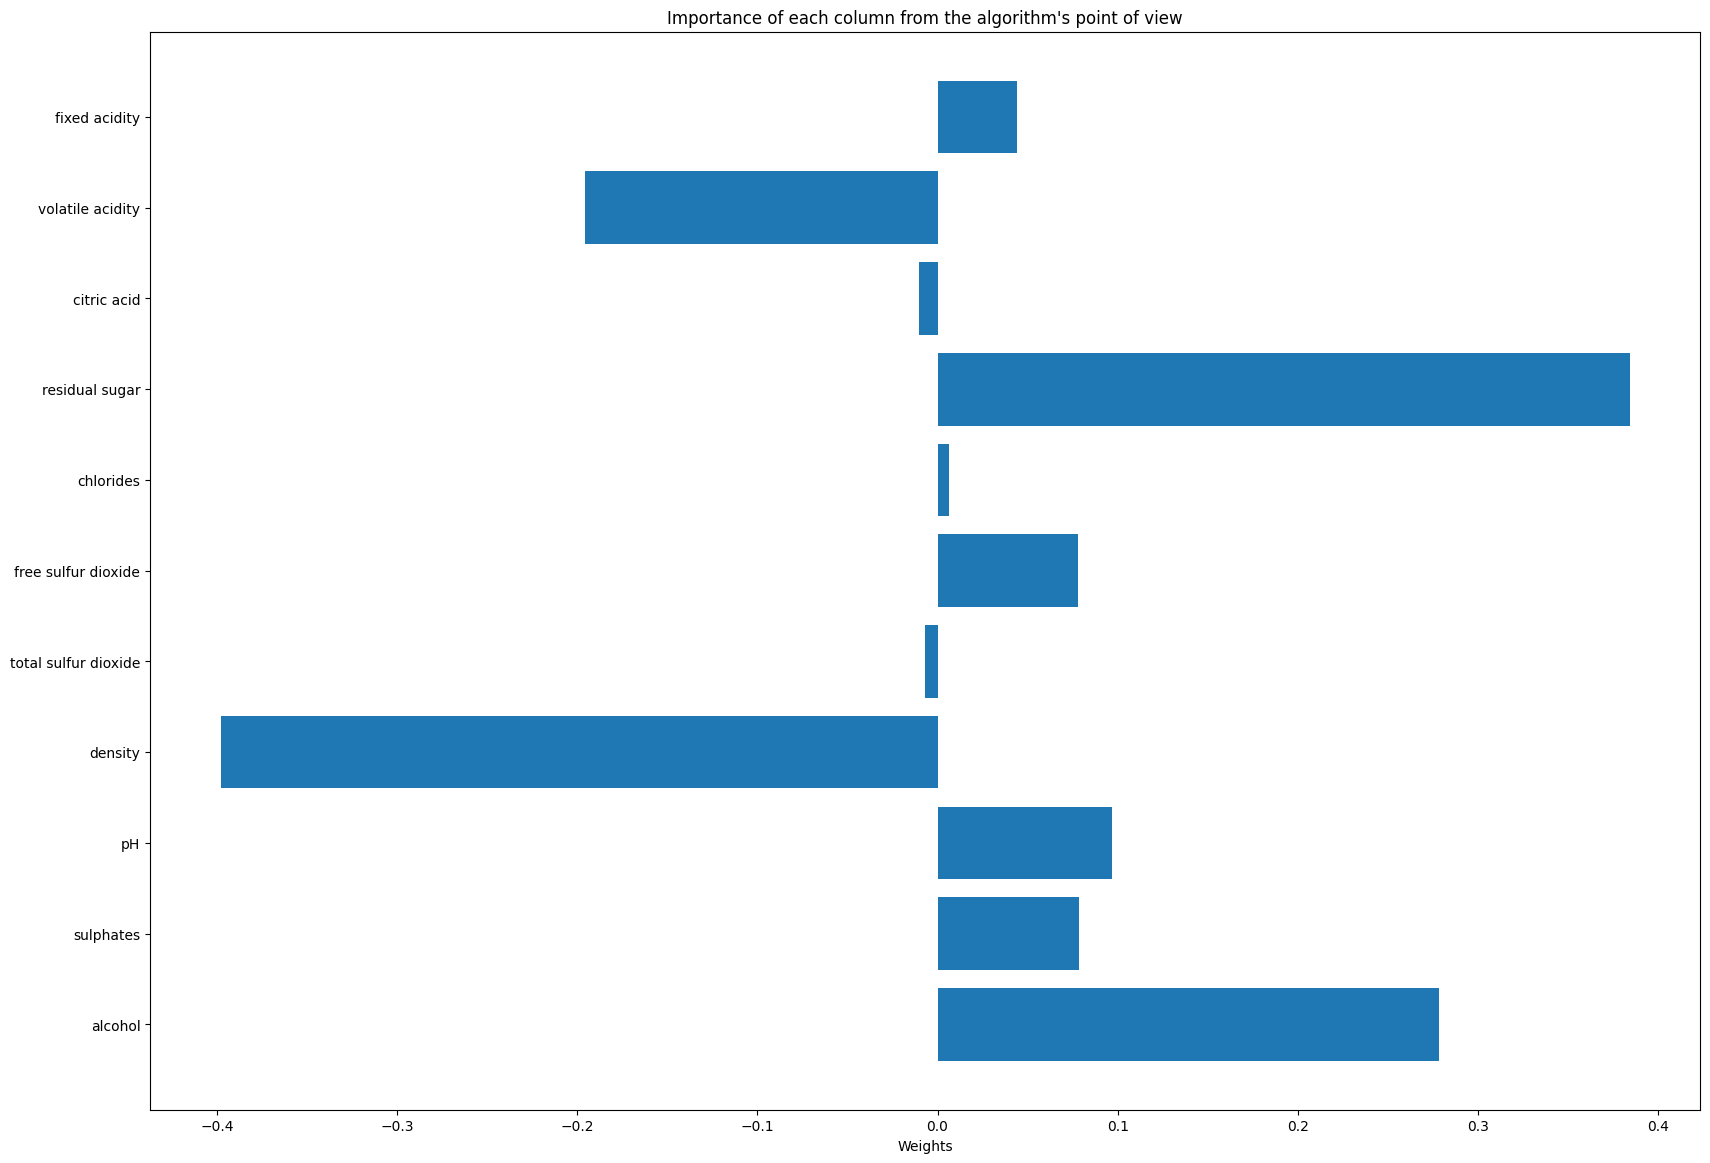

In [18]:
import matplotlib.pyplot as plt

# get moedel weights
weights_linear = linear_reg.coef_

#  plot
fig, ax = plt.subplots(figsize=(20,14))
y_pos = np.arange(0,len(weights_linear),1)
labels = list(X.columns)

hbars = ax.barh(y_pos, weights_linear, align='center')
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.invert_yaxis()  # labels read top-to-bottom
ax.set_xlabel('Weights')
ax.set_title("Importance of each column from the algorithm's point of view")

plt.show()

In [19]:
# Create a DataFrame with feature names and their corresponding weights
feature_weights_df = pd.DataFrame({'Feature': X.columns, 'Weight': weights_linear})

# Sort the DataFrame by the absolute value of the weights in descending order
feature_weights_df['AbsWeight'] = feature_weights_df['Weight'].abs()
feature_weights_df = feature_weights_df.sort_values('AbsWeight', ascending=False)

feature_weights_df

,Feature,Weight,AbsWeight
7,density,-0.398034,0.398034
3,residual sugar,0.384196,0.384196
10,alcohol,0.278218,0.278218
1,volatile acidity,-0.195853,0.195853
8,pH,0.096886,0.096886
9,sulphates,0.078420,0.078420
5,free sulfur dioxide,0.077791,0.077791
0,fixed acidity,0.044302,0.044302
2,citric acid,-0.010283,0.010283
6,total sulfur dioxide,-0.007168,0.007168


#### **<font face="Courier New" color="red" size="+3">4.2. Lasso Regression</font>**




##### <font face="Verdana" color="green" size="+2">**4.2.1 (1 points)**

Train a LASSO model with $\alpha = 0.01$ (indicating weak regularization) using the scaled data. Ensure to set $\texttt{random_state=42}$.
</font>




In [20]:
lasso_reg = Lasso(alpha=0.01, selection='random', random_state=42)    # random_state works only if we choose selection = 'random'
lasso_reg.fit(X_train, y_train)

y_pred_lasso = lasso_reg.predict(X_test)

mse_lasso = mean_squared_error(y_test, y_pred_lasso)
print("Lasso Regression MSE:", mse_lasso)

Lasso Regression MSE: 0.5583354097995803


##### <font face="Verdana" color="green" size="+2">**4.2.2 (2 points)**

Which feature contributes the least to predicting wine quality, based on the analysis of this LASSO model?
</font>




In [21]:
# Create a DataFrame with feature names and their corresponding weights
lasso_feature_weights_df = pd.DataFrame({'Feature': X.columns, 'Weight': lasso_reg.coef_})

# Sort the DataFrame by the absolute value of the weights in descending order
lasso_feature_weights_df['AbsWeight'] = lasso_feature_weights_df['Weight'].abs()
lasso_feature_weights_df = lasso_feature_weights_df.sort_values('AbsWeight', ascending=True)

lasso_feature_weights_df

,Feature,Weight,AbsWeight
6,total sulfur dioxide,-0.000000,0.000000
4,chlorides,-0.000337,0.000337
2,citric acid,-0.003805,0.003805
0,fixed acidity,-0.013361,0.013361
8,pH,0.041687,0.041687
9,sulphates,0.052261,0.052261
5,free sulfur dioxide,0.069514,0.069514
7,density,-0.132060,0.132060
3,residual sugar,0.190804,0.190804
1,volatile acidity,-0.194188,0.194188


##### <font face="Verdana" color="green" size="+2">**4.2.3 (1 points)**

Train a `LassoCV` model with `random_state=42` to determine the optimal value of $\alpha$ using 5-fold cross-validation.
</font>




In [22]:
lasso_cv = LassoCV(cv=5,n_alphas=100, selection='random',random_state=42)
lasso_cv.fit(X_train, y_train)

print("Optimal alpha:", lasso_cv.alpha_)

Optimal alpha: 0.005484143486090698


##### <font face="Verdana" color="green" size="+2">**4.2.4 (2 points)**

Which feature does the tuned `LASSO` model identify as the least informative for predicting wine quality?
</font>




In [23]:
# Create a DataFrame with feature names and their corresponding weights
lasso_cv_feature_weights_df = pd.DataFrame({'Feature': X.columns, 'Weight': lasso_cv.coef_})

# Sort the DataFrame by the absolute value of the weights in ascending order
lasso_cv_feature_weights_df['AbsWeight'] = lasso_cv_feature_weights_df['Weight'].abs()
lasso_cv_feature_weights_df = lasso_cv_feature_weights_df.sort_values('AbsWeight', ascending=True)

lasso_cv_feature_weights_df


,Feature,Weight,AbsWeight
0,fixed acidity,-0.000000,0.000000
4,chlorides,-0.000000,0.000000
6,total sulfur dioxide,-0.000853,0.000853
2,citric acid,-0.005638,0.005638
8,pH,0.058841,0.058841
9,sulphates,0.062483,0.062483
5,free sulfur dioxide,0.071916,0.071916
1,volatile acidity,-0.196094,0.196094
7,density,-0.224284,0.224284
3,residual sugar,0.259428,0.259428


##### <font face="Verdana" color="green" size="+2">**4.2.5 (1 points)**

What are the mean squared errors of the tuned `LASSO` model's predictions on the training and holdout sets?
</font>




In [24]:
y_pred_lasso_cv = lasso_cv.predict(X_test)

mse_lasso_cv_train = mean_squared_error(y_train, lasso_cv.predict(X_train))
mse_lasso_cv_test = mean_squared_error(y_test, y_pred_lasso_cv)

print('Tuned LASSO MSE on training set: {}'.format(mse_lasso_cv_train))
print('Tuned LASSO MSE on test set: {}'.format(mse_lasso_cv_test))

Tuned LASSO MSE on training set: 0.5697721598106007
Tuned LASSO MSE on test set: 0.5563905686838316


<hr>

### **<font face="Courier New" color="blue" size="+3">Question 5: Implementing and Analyzing Ridge Regression (10 points)</font>**



   As you know, the weights $\mathbf{w}$ in Ridge Regression can be calculated using the mathematical relation provided in the slides:

   $$
   \hat{\mathbf{\theta}} = \left( \mathbf{X}^\top \mathbf{X} + \alpha \mathbf{A} \right)^{-1} \mathbf{X}^\top \mathbf{y}
   $$





##### <font face="Verdana" color="green" size="+2">**5.1 (2.5 points)**

First, generate 100 random integers between 2 and 100 using the `numpy` module and convert the numbers into an array with dimensions (100, 2). Then, generate the variable $y$ using the formula below:</font>

$$
y = 3 + 2x_1 - 4x_2 + 5.64x_1^2 + 0x_1x_2 + 0x_2^2 + \text{{random number in range [0, 1]}}
$$

<font face="Verdana" color="green" size="+2">In the next step, calculate the coefficients for Ridge Regression using the provided mathematical relation, and compare the obtained values with the original coefficients</font>




In [25]:
import numpy as np
import pandas as pd

# some utility functions to use
def predict(X_matrix, theta):
  y_pred = X_matrix @ theta
  return y_pred

def calculate_real_y(X):
  x1 = X[:, 0]
  x2 = X[:, 1]
  y = 3 + 2 * x1 - 4 * x2 + 5.64 * x1**2 + 0 * x1 * x2 + 0 * x2**2 + np.random.uniform(0,1,100)
  return y

def toDataframe(X):
  x1 = X[:, 0]
  x2 = X[:, 1]
  return pd.DataFrame({'x0':1 , 'x1': x1, 'x2': x2, 'x1^2': x1**2, 'x1x2': x1 * x2, 'x2^2': x2**2})

def toMatrix(X):
  a = toDataframe(X)
  return a.values


def ridge_regression(X, y , alpha):
  x1 = X[:, 0]
  x2 = X[:, 1]
  X_df = pd.DataFrame({'x0':1 , 'x1': x1, 'x2': x2, 'x1^2': x1**2, 'x1x2': x1 * x2, 'x2^2': x2**2})

  # Convert DataFrame to numpy array
  X_matrix = X_df.values

  # Calculate the coefficients using the formula
  theta_hat = np.linalg.inv(X_matrix.T @ X_matrix + alpha * np.identity(X_matrix.shape[1])) @ X_matrix.T @ y

  # Print the calculated coefficients
  print("Calculated coefficients:", theta_hat)

  # Compare with original coefficients
  original_coefficients = np.array([3, 2, -4, 5.64, 0, 0])
  print("Original coefficients:", original_coefficients)
  return theta_hat, original_coefficients , y , X_df , predict(X_matrix , theta_hat)




In [27]:
from sklearn.model_selection import train_test_split

X = np.random.randint(2, 101, size=(100, 2))
y = calculate_real_y(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

alpha = 1
theta_hat1, original_coefficients1 , y1 , X_df1 , y_pred1= ridge_regression(X_train, y_train, alpha)

Calculated coefficients: [ 2.69610522e+00  2.01699347e+00 -3.98012999e+00  5.63989950e+00
 -1.32189185e-04 -1.27173967e-04]
Original coefficients: [ 3.    2.   -4.    5.64  0.    0.  ]


##### <font face="Verdana" color="green" size="+2">**5.2 (2.5 points)**

Test the model with $\alpha = 0$ (equivalent to linear regression) and analyze the results in terms of overfitting. Compare and evaluate the outputs</font>




In [28]:
theta_hat2, original_coefficients2 , y2  , X_df2 , y_pred2 = ridge_regression(X_train, y_train, 0.0)

Calculated coefficients: [ 3.67891706e+00  1.99563571e+00 -4.00217318e+00  5.64002643e+00
  7.44922875e-06  4.03463506e-06]
Original coefficients: [ 3.    2.   -4.    5.64  0.    0.  ]


In [30]:
from sklearn.metrics import mean_squared_error, r2_score


# Calculate MSE
mse1 = mean_squared_error(y_test, predict(toMatrix(X_test) , theta_hat1))
mse2 = mean_squared_error(y_test, predict(toMatrix(X_test) , theta_hat2))
print(f"Mean Squared Error (MSE) for first model (alpha=1) on test-set: {mse1}")
print(f"Mean Squared Error (MSE) for second model(alpha=0) on test-set: {mse2}")


# # Calculate R-squared
r2_1 = r2_score(y_test, predict(toMatrix(X_test) , theta_hat1))
r2_2 = r2_score(y_test, predict(toMatrix(X_test) , theta_hat2))
print(f"R-squared (R^2) of first model (alpha=1) on test-set: {r2_1}")
print(f"R-squared (R^2) of second model (alpha=0) on test-set: {r2_2}")

r2_1_train = r2_score(y_train, y_pred1)
r2_2_train = r2_score(y_train, y_pred2)
print(f"R-squared (R^2) of first model(alpha=1) on train-set: {r2_1_train}")
print(f"R-squared (R^2) of second model (alpha=0) on train-set: {r2_2_train}")

Mean Squared Error (MSE) for first model (alpha=1) on test-set: 0.15263558946155928
Mean Squared Error (MSE) for second model(alpha=0) on test-set: 0.10571244675052986
R-squared (R^2) of first model (alpha=1) on test-set: 0.9999999994745136
R-squared (R^2) of second model (alpha=0) on test-set: 0.9999999996360583
R-squared (R^2) of first model(alpha=1) on train-set: 0.9999999996576276
R-squared (R^2) of second model (alpha=0) on train-set: 0.9999999997629668


As you can serr, since the $R^2$ does not differ very much in test and train sets, we can conclude that our models are not overfitting. However, since our first model (with $\alpha =1$) has lower $R^2$ than the second model (with $\alpha = 0$), we see that the ridge regression limits the power of linear regression.

##### <font face="Verdana" color="green" size="+2">**5.3 (2.5 points)**

Test the model with three different values of $\alpha$ (small, medium, and large) and compare the results with those obtained without regularization (i.e., $\alpha = 0$). Analyze the outputs</font>




In [32]:
alphas = [0.0 , 0.2 , 1 , 10]
for al in alphas:
  th, org , y_al  , X_df_al , y_pred_al = ridge_regression(X_train, y_train, al)
  print()
  # Calculate MSE
  mse = mean_squared_error(y_test, predict(toMatrix(X_test) , th))
  print(f"Mean Squared Error (MSE) for model alpha = {al} on test-set: {mse}")

  # # Calculate R-squared
  r2 = r2_score(y_test, predict(toMatrix(X_test) , th))
  print(f"R-squared (R^2) of model alpha ={al} on test-set: {r2}")

  r2_train = r2_score(y_train, y_al)
  print(f"R-squared (R^2) of model alpha ={al} on train-set: {r2_1_train}")
  print(40 * '*')

Calculated coefficients: [ 3.67891706e+00  1.99563571e+00 -4.00217318e+00  5.64002643e+00
  7.44922875e-06  4.03463506e-06]
Original coefficients: [ 3.    2.   -4.    5.64  0.    0.  ]

Mean Squared Error (MSE) for model alpha = 0.0 on test-set: 0.10571244675052986
R-squared (R^2) of model alpha =0.0 on test-set: 0.9999999996360583
R-squared (R^2) of model alpha =0.0 on train-set: 0.9999999996576276
****************************************
Calculated coefficients: [ 3.42965186e+00  2.00107823e+00 -3.99661927e+00  5.63999404e+00
 -2.80039945e-05 -2.88667720e-05]
Original coefficients: [ 3.    2.   -4.    5.64  0.    0.  ]

Mean Squared Error (MSE) for model alpha = 0.2 on test-set: 0.10769131307798699
R-squared (R^2) of model alpha =0.2 on test-set: 0.9999999996292456
R-squared (R^2) of model alpha =0.2 on train-set: 0.9999999996576276
****************************************
Calculated coefficients: [ 2.69610522e+00  2.01699347e+00 -3.98012999e+00  5.63989950e+00
 -1.32189185e-04 -1.27

As we increase Alpha, we are restricting the coefficients more, thus leading to poorer performance.

##### <font face="Verdana" color="green" size="+2">**5.4 (2.5 points)**

Using the `Lasso` model from the `sklearn` library, compare the results with different values of $\alpha$ and analyze the outputs (No need to use mathematical relationship)</font>




In [33]:
from sklearn.linear_model import Lasso

alphas = [0.01, 0.1, 1, 10]
for alpha in alphas:
  lasso_reg = Lasso(alpha=alpha, random_state=42)
  lasso_reg.fit(toMatrix(X_train), y_train)

  y_pred_lasso = lasso_reg.predict(toMatrix(X_test))
  mse_lasso = mean_squared_error(y_test, y_pred_lasso)
  r2_lasso = r2_score(y_test, y_pred_lasso)

  print(f"Alpha: {alpha}")
  print(f"MSE: {mse_lasso}")
  print(f"R-squared: {r2_lasso}")

  # Analyze coefficients
  print("Coefficients: {}".format(lasso_reg.coef_))
  print("-" * 20)

# Analysis:
# As alpha increases, the model becomes more regularized, leading to:
# - Shrinking of coefficients towards zero.
# - Some coefficients potentially becoming exactly zero, performing feature selection.
# - Increased bias but potentially decreased variance.
# Observe how the MSE and R-squared change with different alpha values.
# Also, analyze how the coefficients change. Some features might become less influential
# or even completely disregarded as alpha increases.

Alpha: 0.01
MSE: 0.10489481253029394
R-squared: 0.9999999996388732
Coefficients: [ 0.00000000e+00  2.00494802e+00 -3.98912976e+00  5.63995029e+00
 -2.34470405e-05 -1.06908507e-04]
--------------------
Alpha: 0.1
MSE: 0.10347621161046996
R-squared: 0.9999999996437571
Coefficients: [ 0.00000000e+00  2.00363580e+00 -3.98771039e+00  5.63996104e+00
 -2.19919338e-05 -1.20966226e-04]
--------------------
Alpha: 1
MSE: 0.1067570272442746
R-squared: 0.9999999996324621
Coefficients: [ 0.00000000e+00  1.99051355e+00 -3.97351665e+00  5.64006855e+00
 -7.44086643e-06 -2.61543418e-04]
--------------------
Alpha: 10
MSE: 1.8781772164692818
R-squared: 0.9999999935339022
Coefficients: [ 0.00000000e+00  1.86178025e+00 -3.82923921e+00  5.64113675e+00
  1.02180002e-04 -1.67193751e-03]
--------------------


Again, as we increase alpha, we are increaseing regularization. Also notice that the first coefficient is $0$! (Lasso works in this way. It will lead some of the coefficients to $0$.)

<hr>

### **<font face="Courier New" color="blue" size="+3">Question 6: Support Vector Regression (20 points)</font>**

In this part you're going to work with SVR model

At the end of this question you'll see how SVR can boost the regression task

#### **<font face="Courier New" color="red" size="+3">6.1. A simple nonlinear function</font>**

The aim is to create some synthetic data which is not very amenable for linear regression models.



##### <font face="Verdana" color="green" size="+2">**6.1.1 (2.5 points)**

Complete the code below to implement the required functionality.</font>





In [34]:
import numpy as np
import pandas as pd

def target_func(array):
    """
    Implement a simple non-linear function to generate the outputs for our model.
    The goal is to estimate this function within the notebook.

    The formula for our model is as follows:
        (10 * X1 - np.exp(0.01 * X2 + np.log(1 + X3 ** 2))) / (X4 ** 2 + 5)

    Please implement the above function using the numpy library.

    References:
    - https://numpy.org/doc/stable/reference/generated/numpy.exp.html
    - https://numpy.org/doc/stable/reference/generated/numpy.log.html

    Arguments:
    - array (np.ndarray): A numpy array of shape (n, 4), where n is the number of data points,
      and 4 represents the features.

    Returns:
    - np.ndarray: The result of applying the function to the input array.
    """
    X1 = array[:, 0]
    X2 = array[:, 1]
    X3 = array[:, 2]
    X4 = array[:, 3]

    return (10 * X1 - np.exp(0.01 * X2 + np.log(1 + X3 ** 2))) / (X4 ** 2 + 5)


#### **<font face="Courier New" color="red" size="+3">6.2. Generate features and target data for regression</font>**





##### <font face="Verdana" color="green" size="+2">**6.2.1 (2.5 points)**

Complete the codes below to implement the required functionality.</font>



In [35]:
n_samples = 200
n_features = 4

In [37]:
'''
Generate n_samples random uniform samples with n_features within the range [0, 5).
Hint: Refer to the following link for guidance:
https://numpy.org/doc/stable/reference/random/generated/numpy.random.rand.html
'''
x = np.random.rand(n_samples, n_features) * 5

'''
Apply the non-linearity function you implemented above to the generated data,
then add a random uniform distribution within the range [0, 1).
Hint: Refer to the following link for guidance:
https://numpy.org/doc/stable/reference/random/generated/numpy.random.rand.html
'''
y = target_func(x) + np.random.uniform(0,1,n_samples)

'''
Create a dataset using our generated data.
Please use a pandas DataFrame.
The first 4 columns should represent the features (x), and the last column should be the target (y).
Hint:
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html
'''
df = pd.DataFrame({'x1': x[:,0], 'x2': x[:,1], 'x3': x[:,2], 'x4': x[:,3] , 'y': y})



In [38]:
df.head()

,x1,x2,x3,x4,y
0,2.486194,0.116867,1.400444,3.042168,2.072151
1,3.794523,4.411523,1.357604,1.110257,5.902780
2,0.101292,1.587751,3.984413,0.444890,-2.620323
3,2.985453,3.493744,4.356275,2.312976,0.889674
4,0.500452,0.821556,4.292874,4.944943,0.501916


#### **<font face="Courier New" color="red" size="+3">6.3. Plotting the data</font>**





##### <font face="Verdana" color="green" size="+2">**6.3.1 (3 points)**

Complete the code below to implement the required functionality.</font>





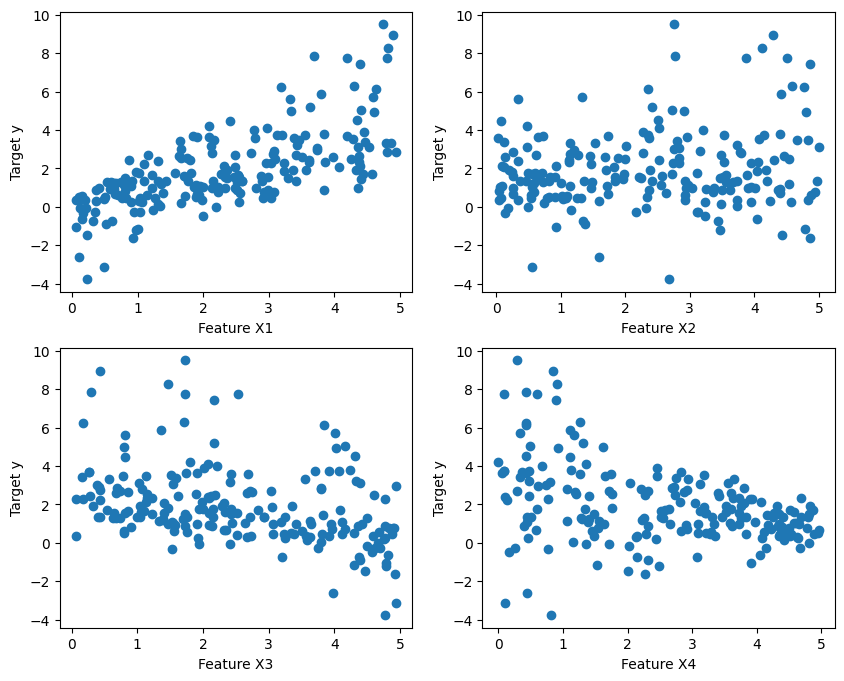

In [39]:
'''
Plot the generated target values against each feature.
Create a subplot with 4 sections, each representing the target value (y) as a function of one feature (X_i).
Hint:
  https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.subplots.html
  https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html
'''
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 2, figsize=(10, 8))
ax = ax.ravel()

for i in range(4):
    ax[i].scatter(df.iloc[:, i], df.iloc[:, -1])

    ax[i].set_xlabel(f'Feature X{i+1}')
    ax[i].set_ylabel('Target y')

plt.show()


#### **<font face="Courier New" color="red" size="+3">6.4. Train/Test Split</font>**





##### <font face="Verdana" color="green" size="+2">**6.4.1 (2 points)**

Complete the code below to implement the required functionality.</font>





In [40]:
'''
First extract features and target value from the pandas dataset then, split data with a suitable ratio between train and test
Hint:
  https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
'''
from sklearn.model_selection import train_test_split
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X , y, test_size=0.2 , random_state=42 )


#### **<font face="Courier New" color="red" size="+3">6.5.  Linear regression as a baseline</font>**





##### <font face="Verdana" color="green" size="+2">**6.5.1 (2 points)**

Complete the code below to implement the required functionality.</font>





In [41]:
from sklearn.linear_model import LinearRegression

'''
Define and train a linear regression model on the training data.
This will serve as our baseline model.

Hint:
  https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
'''

########################################
######### COMPLETE THE CODE BELOW ######
linear = LinearRegression()
linear.fit(X_train, y_train)
########################################

'''
Evaluate the model by printing its score on the test data.
'''

########################################
######### COMPLETE THE CODE BELOW ######
print("Model Test Score:", linear.score(X_test, y_test))
########################################


Model Test Score: 0.67594631395597


#### **<font face="Courier New" color="red" size="+3">6.6.  Support vector regressor with linear kernel</font>**





##### <font face="Verdana" color="green" size="+2">**6.6.1 (2 points)**

Complete the code below to implement the required functionality.</font>





In [42]:
from sklearn.svm import SVR

'''
First, define an SVR model with a **linear kernel** and use the default values for other parameters.
Then, train this model on the training data.
Finally, report the model's score on the test data and compare it with the performance of our linear regression model.

Hint:
  https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html
'''

########################################
######### COMPLETE THE CODE BELOW ######
svr_linear = SVR(kernel='linear')
svr_linear.fit(X_train, y_train)
########################################

'''
Print the score of the SVR model on the test data and compare it with the linear regression model.
'''

########################################
######### COMPLETE THE CODE BELOW ######
print("SVR Model Test Score:", svr_linear.score(X_test, y_test))
print("Linear Regression Model Test Score:", linear.score(X_test, y_test))
########################################


SVR Model Test Score: 0.6590087119981511
Linear Regression Model Test Score: 0.67594631395597


#### **<font face="Courier New" color="red" size="+3">6.7.  Support vector regressor with Gaussian (radial basis function) kernel</font>**





##### <font face="Verdana" color="green" size="+2">**6.7.1 (2 points)**

Complete the code below to implement the required functionality.</font>





In [44]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error

'''
Define an SVR model with an **RBF kernel** using the default values for other parameters.
Train this model on the training data.
Then, report the model's score on the test data and compare it with the scores of the previous models.

Hint:
  https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html
'''

########################################
######### COMPLETE THE CODE BELOW ######
svr_rbf = SVR(kernel='rbf')
svr_rbf.fit(X_train, y_train)
print("SVR (RBF Kernel) Model Test Score:", svr_rbf.score(X_test , y_test) )
print("SVR (Linear) Test Score:", svr_linear.score(X_test, y_test))
print("Linear Regression Model Test Score:", linear.score(X_test, y_test))
########################################

'''
Calculate and report the Mean Squared Error (MSE) for all models.
Compare the MSE results to evaluate their performance.

Hint:
  https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html
'''

########################################
######### COMPLETE THE CODE BELOW ######
mse_linear = mean_squared_error(y_test, linear.predict(X_test))
mse_svr_linear = mean_squared_error(y_test, svr_linear.predict(X_test))
mse_svr_rbf = mean_squared_error(y_test, svr_rbf.predict(X_test))

print("Linear Regression MSE:", mse_linear)
print("SVR (Linear Kernel) MSE:", mse_svr_linear)
print("SVR (RBF Kernel) MSE:", mse_svr_rbf)
########################################


SVR (RBF Kernel) Model Test Score: 0.857207611089094
SVR (Linear) Test Score: 0.6590087119981511
Linear Regression Model Test Score: 0.67594631395597
Linear Regression MSE: 1.4930269059827086
SVR (Linear Kernel) MSE: 1.5710642699595312
SVR (RBF Kernel) MSE: 0.6578937003190346


SVR with 'RBF' kernel is better than the other two.

#### **<font face="Courier New" color="red" size="+3">6.8.  grid search of hyperparameters (with 5-fold cross-validation) </font>**





##### <font face="Verdana" color="green" size="+2">**6.8.1 (3 points)**

Complete the code below to implement the required functionality.</font>





In [45]:
from sklearn.model_selection import GridSearchCV

'''
Perform a grid search to fine-tune the hyperparameters of the SVR model.
Focus on optimizing the `C` and `epsilon` parameters, defining their ranges as you see fit.
Conduct the search using the SVR model with an RBF kernel.
Set cross-validation to 5 folds and use the R² scoring function.
For deeper insights, also return the training score.

Hint:
  https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
'''

########################################
######### COMPLETE THE CODE BELOW ######

rbf_svr = SVR(kernel='rbf')
params = {
    'C': [0.1, 0.3, 0.7 , 1, 3 , 7 , 10, 30 , 70 , 100],
    'epsilon': [0.01, 0.03, 0.1, 0.3 ,  0.5, 0.7 , 1]
    }
grid = GridSearchCV(rbf_svr, params, cv=5, scoring='r2' , verbose=1 ,  return_train_score=True)
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross-Validation Score:", grid.best_score_)
print("Train Score with Best Parameters:", grid.cv_results_['mean_train_score'][grid.best_index_])
########################################


Fitting 5 folds for each of 70 candidates, totalling 350 fits
Best Parameters: {'C': 70, 'epsilon': 0.3}
Best Cross-Validation Score: 0.9508546931538205
Train Score with Best Parameters: 0.9856848458002603


#### **<font face="Courier New" color="red" size="+3">6.9.  Check which was deemed best estimator by the grid search</font>**





In [46]:
print(grid.best_estimator_)

SVR(C=70, epsilon=0.3)


#### **<font face="Courier New" color="red" size="+3">6.10.  Fit that estimator to the data and see</font>**





##### <font face="Verdana" color="green" size="+2">**6.10.1 (1 points)**

Complete the code below to implement the required functionality.</font>





In [47]:
########################################
######### YOUR CODES GO HERE ###########
svr_best = grid.best_estimator_
svr_best.fit(X_train , y_train)

svr_best.score(X_test , y_test)
########################################

0.9440275711196884

The hyperparameter tuning has a great effect!

### **<font face="Courier New" color="blue" size="+3">Question 7: Predicting Life Expectancy (30 points)</font>**



**Dataset Introduction**

The dataset for this problem consists of 2,848 rows and 18 columns. 17 columns represent the independent variables, while the final column represents the dependent variable.

Below is a description of each column. Each row corresponds to the information for a specific country recorded in a particular year.

| Column                | Description                                                                                     |
|:----------------------:|:----------------------------------------------------------------------------------------------:|
| `Country`             | The country being studied                                                                       |
| `Year`                | The year of the record                                                                          |
| `Status`              | The development status of the country                                                           |
| `Population`          | The population of the country                                                                   |
| `Hepatitis B`         | Percentage of one-year-olds immunized against Hepatitis B                                       |
| `Measles`             | Number of reported measles cases per 1,000 people                                               |
| `Polio`               | Percentage of one-year-olds immunized against polio                                             |
| `Diphtheria`          | Percentage of one-year-olds immunized against diphtheria                                        |
| `HIV/AIDS`            | Number of AIDS-related deaths per 1,000 live births among children up to 4 years old            |
| `infant deaths`       | Number of infant deaths per 1,000 live births                                                   |
| `under-five deaths`   | Number of deaths under the age of five per 1,000 live births                                    |
| `Total expenditure`   | Government health expenditure as a percentage of total government expenditure                   |
| `GDP`                 | Gross Domestic Product in U.S. dollars                                                          |
| `BMI`                 | Average Body Mass Index of the population                                                       |
| `thinness 1-19 years` | Prevalence of thinness among individuals aged 19 years and younger, expressed as a percentage    |
| `Alcohol`             | Alcohol consumption in liters among individuals over the age of 15                              |
| `Schooling`           | Average number of years of schooling                                                            |
| `Life expectancy`     | Life expectancy or average lifespan                                                             |

---


**Import libraries**

In [48]:
# Import essential libraries
import pandas as pd                # For data manipulation and analysis
import numpy as np                 # For numerical computations
from sklearn.model_selection import train_test_split  # For splitting the dataset
from sklearn.preprocessing import PolynomialFeatures  # For generating polynomial features
from sklearn.linear_model import LinearRegression     # For training a linear regression model
from sklearn.metrics import r2_score                  # For evaluating the model performance
import matplotlib.pyplot as plt     # For plotting
import seaborn as sns               # For enhanced data visualization

# Set visualization style
sns.set(style="whitegrid")

#### **<font face="Courier New" color="red" size="+3">7.1. Read dataset (1 points)</font>**





First, you need to read the provided dataset file. This single dataset contains all the samples you'll work with. You will need to split this dataset into training and testing sets. You may also consider creating a validation set from the training data if needed.

In [74]:
# Read the dataset
data = pd.read_csv('/content/drive/MyDrive/TEIAS/ML/HW3/life_expectancy.csv')
data


,Country,Year,Status,Population,Hepatitis B,Measles,Polio,Diphtheria,HIV/AIDS,infant deaths,under-five deaths,Total expenditure,GDP,BMI,thinness 1-19 years,Alcohol,Schooling,Life expectancy
0,Afghanistan,2015,Developing,33736494.0,65.0,1154,6.0,65.0,0.1,62,83,8.16,584.259210,19.1,17.2,0.01,10.1,65.0
1,Afghanistan,2014,Developing,327582.0,62.0,492,58.0,62.0,0.1,64,86,8.18,612.696514,18.6,17.5,0.01,10.0,59.9
2,Afghanistan,2013,Developing,31731688.0,64.0,430,62.0,64.0,0.1,66,89,8.13,631.744976,18.1,17.7,0.01,9.9,59.9
3,Afghanistan,2012,Developing,3696958.0,67.0,2787,67.0,67.0,0.1,69,93,8.52,669.959000,17.6,17.9,0.01,9.8,59.5
4,Afghanistan,2011,Developing,2978599.0,68.0,3013,68.0,68.0,0.1,71,97,7.87,63.537231,17.2,18.2,0.01,9.5,59.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2843,Zimbabwe,2004,Developing,12777511.0,68.0,31,67.0,65.0,33.6,27,42,7.13,454.366654,27.1,9.4,4.36,9.2,44.3
2844,Zimbabwe,2003,Developing,12633897.0,7.0,998,7.0,68.0,36.7,26,41,6.52,453.351155,26.7,9.8,4.06,9.5,44.5
2845,Zimbabwe,2002,Developing,125525.0,73.0,304,73.0,71.0,39.8,25,40,6.53,57.348340,26.3,1.2,4.43,10.0,44.8
2846,Zimbabwe,2001,Developing,12366165.0,76.0,529,76.0,75.0,42.1,25,39,6.16,548.587312,25.9,1.6,1.72,9.8,45.3


#### **<font face="Courier New" color="red" size="+3">7.3. Preprocessing and Feature Engineering (8 points)</font>**





**<font face="Courier New" color="BLUE" >I decided to swap this part and part 7.2</font>**

In this section, you can apply any preprocessing or feature engineering techniques you have learned. The techniques you use will not be directly evaluated, but they will influence the accuracy of your model. Therefore, the better your preprocessing and feature engineering, the higher the accuracy of your model, and the more points you will earn for this question.

In [75]:
data['Country'].nunique()

178

In [76]:
# Drop the 'Country' column. I think this column is not very informative at the moment.
# This is a categorical column with 178 different values. later we will use one-hot encoding and so,
# the result would have almost 178 extra columns, which will impact the accuracy.(since our dataset is small)
data = data.drop('Country', axis=1)

In [77]:
# Delete rows with missing values
# I compare the results of mine with some of my friends, who replcae NaN with mean or median, and see I've got higher accuracy scores,
# So I decided to just drop the NaN columns.
data = data.dropna()

<Figure size 1000x800 with 0 Axes>

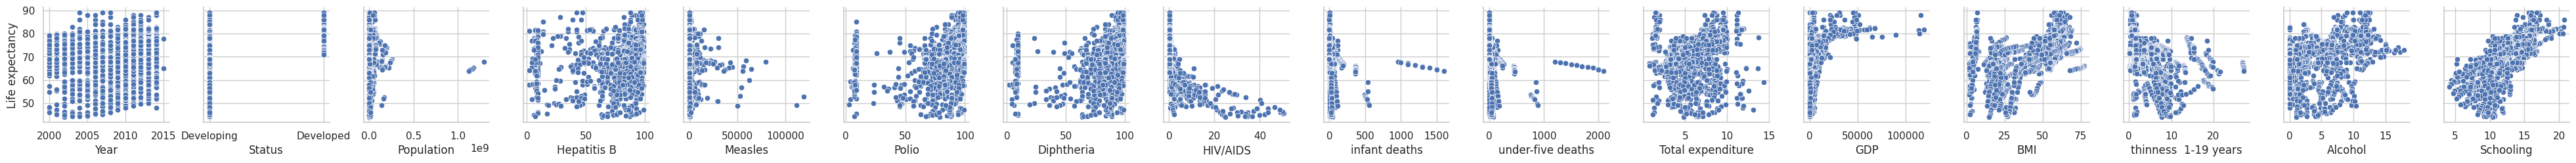

In [61]:
# prompt: pairplot all columns with respect to  'Life expectancy'

import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'data' is your DataFrame and 'Life expectancy' is a column in it.
plt.figure(figsize=(10, 8))
sns.pairplot(data, x_vars=data.columns.drop('Life expectancy'), y_vars=['Life expectancy'])
plt.show()

In [78]:
# before train test split, let's one-hot encode categorical variables:

X = data.drop('Life expectancy', axis=1)
y = data['Life expectancy']

numerical_features = X.select_dtypes(include=['number']).columns
categorical_features = X.select_dtypes(include=['object']).columns

X = pd.get_dummies(X, columns=categorical_features)

In [79]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1585 entries, 0 to 2847
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  1585 non-null   int64  
 1   Population            1585 non-null   float64
 2   Hepatitis B           1585 non-null   float64
 3   Measles               1585 non-null   int64  
 4   Polio                 1585 non-null   float64
 5   Diphtheria            1585 non-null   float64
 6   HIV/AIDS              1585 non-null   float64
 7   infant deaths         1585 non-null   int64  
 8   under-five deaths     1585 non-null   int64  
 9   Total expenditure     1585 non-null   float64
 10  GDP                   1585 non-null   float64
 11  BMI                   1585 non-null   float64
 12  thinness  1-19 years  1585 non-null   float64
 13  Alcohol               1585 non-null   float64
 14  Schooling             1585 non-null   float64
 15  Status_Developed      1585

#### **<font face="Courier New" color="red" size="+3">7.2. Splitting the Dataset (1 points)</font>**





Since you have only one dataset, you'll need to split it into training and testing sets. You can also create a validation set if you wish to fine-tune your model before evaluating it on the test set.

In [80]:
# To-Do: Split your data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [81]:
from sklearn.preprocessing import StandardScaler

# Apply StandardScaler to numerical features
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train_scaled[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test_scaled[numerical_features])

#### **<font face="Courier New" color="red" size="+3">7.4. Modeling (5 points)</font>**





Now that you have cleaned the data and possibly added or removed features, it's time to train a model that can predict the target variable.

**Using `scikit-learn`**

There is no specific package for polynomial regression in the `scikit-learn` library. Therefore, to use this algorithm, you must first convert the features of the DataFrame into polynomial features using the `PolynomialFeatures` class, which is part of the `preprocessing` module. After transforming the features, you can train a regular linear regression model using the transformed features.

Below are some important arguments of this class, but for a more comprehensive understanding, you can refer to [this link](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html).

| Argument          | Type                        | Description                                                                                 |
|:-----------------:|:---------------------------:|:-------------------------------------------------------------------------------------------:|
| `degree`          | `int` or `tuple`            | The degree of the polynomial. The default is `2`. If provided as a `tuple`, it is interpreted as `(min_degree, max_degree)`. |
| `include_bias`    | `bool`                      | Whether to include the bias term (i.e., the constant `1`) in the polynomial features. If `True`, the polynomial features will range from `min_degree` to `max_degree`. |

The `PolynomialFeatures` class includes three main methods:

| Method Name       | Description                                                                                      |
|:-----------------:|:------------------------------------------------------------------------------------------------:|
| `fit`             | Computes the number of output polynomial terms.                                                  |
| `transform`       | Transforms the input data into polynomial features.                                              |
| `fit_transform`   | First computes the number of polynomial terms, then transforms the input data into polynomial features. |

#### **<font face="Courier New" color="red" size="+3">7.5. Training the Model (4 points)</font>**





In the following cell, use the `scikit-learn` library to train a model that can predict the target variable for this problem.

- To generate polynomial features, initialize the `poly_transformer` object. This object will be stored and evaluated during grading.
- Then, train a linear regression model using the polynomial features generated by the `poly_transformer`, and store the trained model in the `model` object. The `model` object will be evaluated during grading, so ensure that it is a `LinearRegression` object; otherwise, you will not receive any points!

In [85]:

poly_transformer = PolynomialFeatures(degree=2)  # You can adjust the degree as needed
X_train_poly = poly_transformer.fit_transform(X_train_scaled)
X_test_poly = poly_transformer.transform(X_test_scaled)

# Train a linear regression model with the polynomial features
model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

model_normal = LinearRegression()
model_normal.fit(X_train_scaled, y_train)

LinearRegression()

#### **<font face="Courier New" color="red" size="+3">7.6. Evaluation Metric (1 points)</font>**





The evaluation metric we have chosen to assess the performance of your model is the `r2_score`. This metric measures the quality of your model's predictions. The grading system will also use this metric to assign your score. It is recommended that you evaluate your model's performance on the training or validation set using this metric.

In [87]:
from sklearn.metrics import r2_score

def performance(model , X_train , X_test , y_test):
  y_pred = model.predict(X_test)
  r2 = r2_score(y_test, y_pred)

  print("train R-squared:", r2_score(y_train, model.predict(X_train)))
  print("test R-squared:", r2_score(y_test, model.predict(X_test)))

print("Normal model(no polynimial feature):")
performance(model_normal , X_train_scaled, X_test_scaled , y_test)

print("Polynomial model:")
performance(model_poly , X_train_poly, X_test_poly , y_test)

Normal model(no polynimial feature):
train R-squared: 0.7956379780349483
test R-squared: 0.7582434696412331
Polynomial model:
train R-squared: 0.9006463561736844
test R-squared: 0.8422356454370402


#### **<font face="Courier New" color="red" size="+3">7.7. Explanation and Analysis (10 points)</font>**





After completing your model training and evaluation, you are required to provide a comprehensive explanation and analysis of your approach and results. This section will be highly valued and carry significant points. Your explanation should include:

1. **Feature Engineering Rationale**:
   - Describe the feature engineering techniques you applied.
   - Explain why you chose these specific techniques and how they contribute to improving model performance.
   - Discuss any challenges you encountered during this process and how you addressed them.

2. **Model Choice and Training**:
   - Justify your choice of model(s) and why they are appropriate for this problem.
   - Discuss any hyperparameter tuning you performed and the reasoning behind the chosen settings.
   - Provide details on the training process, including any steps you took to avoid overfitting.

3. **Evaluation and Interpretation**:
   - Present the evaluation metrics for your model, particularly the `r2_score`.
   - Interpret these metrics in the context of the problem. What do they say about your model’s performance?
   - Compare the performance of different models (if applicable) and explain why one may have performed better than the other.
   - Discuss any potential sources of error or bias in your model.

4. **Conclusion and Insights**:
   - Summarize the key insights you gained from the analysis.
   - Suggest potential improvements or next steps that could further enhance the model’s performance.
   - Reflect on the real-world applicability of your model. How well do you think it would perform in a production environment?

---

**Submission Guidelines**:
- Your explanation should be clear, concise, and well-structured.
- Use visual aids, such as charts or graphs, to support your analysis where appropriate.
- Ensure that all code is well-commented and that the reasoning behind each step is clearly articulated.

**Note**: This section is crucial for demonstrating your understanding of the problem and the steps you took to solve it. A well-explained analysis will earn you more points, so take the time to thoroughly document and justify your approach.


## Feature Engineering
#### Techniques Applied:
1. Polynomial Features: I introduced polynomial features (e.g., squares and interactions) of existing features. This was done to capture potential non-linear relationships between the features.
2. One-Hot Encoding: Categorical features like 'Status' were transformed using one-hot encoding. This creates new binary features representing each category.
3. Feature Scaling: All numerical features were scaled using StandardScaler. This ensures that features with different scales (e.g., 'Population' and 'Alcohol') have equal weight during model training, preventing features with larger values from dominating the model.

Challenges and Solutions:
1. Curse of Dimensionality: Introducing polynomial features can significantly increase the number of features, decreasing the training speed and stability.


#### Model Choice and Training:
NO Strong justification. It was the demand of the problem to only use LinearRegression. Thus, no hyperparameter tuning or regularization were applied.
But linear regression is the simplest learning model for regression tasks, which is highly interpretable and has efficient performance (with regard to its accuracy).

Among the two models I've trained (a normal model, and model trained on polynomial features) the second one outperforms the first. When we use polynomial features, we are introduing the interaction terms and also it is somehow like a kernel method: we are transforming our data to a higher-dimension space, where nonlinear relationships might become linear (with respect to the target variable.)

#### Evaluation and Interpretation:

1. The primary evaluation metric I used was the R-squared (R²) score, which measures the proportion of variance in the dependent variable (Life Expectancy) that is explained by the independent variables. A higher R² score indicates a better fit of the model to the data, with a score of 1 representing a perfect fit. In the context of Life Expectancy prediction, a higher R² score suggests that the model is able to explain a larger portion of the variability in life expectancy across different countries and years. I achieved $R^2 ≃ 0.84$ on the test set.
2. Our polynomial model performs better than the normal model, due to its higher $R^2$ score.
3. Potential Sources of Error and Bias:
 * Data Limitations: The dataset may not capture all factors influencing life expectancy, leading to incomplete or inaccurate predictions
 * model assumption: we assumed that our dataset has a linear trend, which might not be true.


 #### Conclusion and Insights:

 1. First, we can use different regression models and then use techniques like cross-validtion to select the best model.
 2. We can apply regularization techniques to prevent our model from overfitting.
 3. Naturally, our model won't do well in real scenarios, since our dataset is very small and incomplete.






#### <font face="Verdana" color="green" size="+2">AI Disclaimer

Promt: "give me a paragraph that states I have used gemini as AI assistant for this assingment. Make sure to include a sentence that this confess is also generated by gemini."

Result:

"In the spirit of transparency and academic integrity, I wish to disclose that I have utilized Google's Gemini AI assistant for various aspects of this assignment, including code generation, data analysis, and answering questions. I have diligently reviewed and critically evaluated all content generated by Gemini, ensuring its accuracy and incorporating my own understanding and insights to ensure the integrity and originality of the work. ***It is important to acknowledge that this very statement regarding the use of Gemini was also generated with the assistance of Gemini***."

